****
IMPORT
****

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, classification_report

****
TRAIN / TEST
****

In [2]:
# 1. Chargement du dataset de training choisi
df_ml = pd.read_parquet("../data/dataframe_training.parquet")

# 2. Séparation de la cible (y) et des caractéristiques (X)
# On supprime explicitement la cible et l'identifiant pour la matrice X
X = df_ml.drop(columns=['a_quitte_l_entreprise', 'id_user'], errors='ignore')
y = df_ml['a_quitte_l_entreprise']

# 3. Création des jeux d'apprentissage et de test (Stratified pour équilibrer le turnover)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"📦 Jeux d'apprentissage et de test créés avec succès !")
print(f"Train set (X_train) : {X_train.shape[0]} lignes | Test set (X_test) : {X_test.shape[0]} lignes")

📦 Jeux d'apprentissage et de test créés avec succès !
Train set (X_train) : 1176 lignes | Test set (X_test) : 294 lignes


****
MODELES
****

In [4]:
# 1. Modèle Baseline / Dummy (Prédit toujours la classe la plus fréquente)
model_dummy = DummyClassifier(strategy="most_frequent")
model_dummy.fit(X_train, y_train)

# 2. Modèle Linéaire (Régression Logistique)
# max_iter augmenté pour garantir la convergence mathématique
model_linear = LogisticRegression(max_iter=1000, random_state=42)
model_linear.fit(X_train, y_train)

# 3. Modèle Non-Linéaire (Random Forest - Optimal pour le Label Encoding)
model_nonlinear = RandomForestClassifier(n_estimators=100, random_state=42)
model_nonlinear.fit(X_train, y_train)

print("🎯 Les 3 modèles ont été entraînés avec succès sur le jeu d'apprentissage !")

🎯 Les 3 modèles ont été entraînés avec succès sur le jeu d'apprentissage !


c:\Users\Nérion\Documents\Code\5_OpenClassRooms\3_automatically_classify_information\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


`DETAIL`
- Dummy => Établit la baseline la plus logique face à un dataset déséquilibré. Le modèle prédit aveuglément la situation majoritaire, ici l'employé qui reste.
- Linear (max_iter=1000) => Augmenté par rapport à la valeur par défaut (100) pour garantir la convergence mathématique de l'algorithme. Les données contenant plusieurs features créées et des échelles différentes, cela donne au solveur linéaire le temps de trouver la frontière de décision optimale sans planter.
- NonLinear (n_estimators=100) => Paramètre standard et robuste qui instancie un ensemble de 100 arbres de décision indépendants. Ce nombre offre un excellent compromis entre puissance prédictive et temps de calcul, tout en réduisant la variance globale par rapport à un arbre de décision unique.
- random_state=42 => Fixe la graine aléatoire pour garantir la reproductibilité stricte des résultats.

****
METRIQUES
****

In [6]:
# Fonction d'extraction automatique des métriques
def extraire_metriques(model, X, y, nom_jeu):
    y_pred = model.predict(X)
    return {
        f"Accuracy ({nom_jeu})": accuracy_score(y, y_pred),
        f"Precision ({nom_jeu})": precision_score(y, y_pred, zero_division=0),
        f"Recall ({nom_jeu})": recall_score(y, y_pred, zero_division=0),
        f"F1-Score ({nom_jeu})": f1_score(y, y_pred, zero_division=0)
    }

# Compilation des résultats pour chaque modèle
dict_resultats = {}

for nom, model in [("Modèle Dummy", model_dummy), ("Modèle Linéaire (LogReg)", model_linear), ("Modèle Non-Linéaire (RF)", model_nonlinear)]:
    # Métriques d'apprentissage
    metriques_train = extraire_metriques(model, X_train, y_train, "Train")
    # Métriques de validation (Test)
    metriques_test = extraire_metriques(model, X_test, y_test, "Test")
    
    # Fusion des dictionnaires pour ce modèle
    dict_resultats[nom] = {**metriques_train, **metriques_test}

# Conversion en DataFrame pour affichage propre sous forme de tableau
df_metriques = pd.DataFrame(dict_resultats).T

# Réorganisation esthétique des colonnes (Train à côté de Test)
colonnes_ordonnees = [
    "Accuracy (Train)", "Accuracy (Test)",
    "Precision (Train)", "Precision (Test)",
    "Recall (Train)", "Recall (Test)",
    "F1-Score (Train)", "F1-Score (Test)"
]

# Affichage du tableau final arrondi à 3 décimales
display(df_metriques[colonnes_ordonnees].round(3))

,Accuracy (Train),Accuracy (Test),Precision (Train),Precision (Test),Recall (Train),Recall (Test),F1-Score (Train),F1-Score (Test)
Modèle Dummy,0.838,0.840,0.000,0.000,0.000,0.000,0.000,0.000
Modèle Linéaire (LogReg),0.860,0.844,0.745,0.533,0.200,0.170,0.315,0.258
Modèle Non-Linéaire (RF),0.999,0.827,1.000,0.375,0.995,0.128,0.997,0.190


`OBSERVATION:`
- Dummy => Ce modèle "naïf" se contente de prédire la classe majoritaire (l'employé reste) car le dataset est déséquilibré. Il prouve que l'Accuracy est une métrique trompeuse ici : un modèle peut sembler performant tout en étant totalement incapable de détecter la moindre démission
- Linear => Sa précision indique qu'il est capable de prédir plus d'un départ sur 2. Moins sensible au surapprentissage que le Random Forest, il reste cependant limité par le déséquilibre des classes. Son Recall de 0.170 montre qu'il ne parvient pas à intercepter efficacement les signaux faibles de turnover.
- NonLinear => Des scores quasi-parfaits sur le jeu d'entraînement qui s'effondrent sur le jeu de test. C'est un cas d'overfitting.

``Ces résultats indique clairement que le dataset est trop déséquilibré et nécessite un rééquilibrage ou l'adaptation de paramètre des modèles.``

In [8]:
# 1. Chargement et Stratification finale (au cas où ce n'est pas déjà dans cette session)
# df_ml = pd.read_parquet("../data/final_hr_features.parquet")
# X = df_ml.drop(columns=['a_quitte_l_entreprise', 'id_user'])
# y = df_ml['a_quitte_l_entreprise']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# 2. Fonction d'évaluation en Cross-Validation
def evaluer_modele_cv(model, X_train, y_train, n_splits=5):
    """
    Évalue un modèle avec Stratified K-Fold et retourne les moyennes/écarts-types.
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scoring = ['recall', 'precision', 'f1']
    
    # Exécution de la validation croisée
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)
    
    # Affichage propre des résultats
    print(f"--- Résultats Validation Croisée ({n_splits} Folds) ---")
    
    # On regarde le train vs test pour vérifier l'Overfit
    print(f"F1-Score (Train) : {scores['train_f1'].mean():.3f} +/- {scores['train_f1'].std():.3f}")
    print(f"F1-Score (Test)  : {scores['test_f1'].mean():.3f} +/- {scores['test_f1'].std():.3f}")
    print("-" * 30)
    print(f"Recall (Test)    : {scores['test_recall'].mean():.3f} +/- {scores['test_recall'].std():.3f}")
    print(f"Precision (Test) : {scores['test_precision'].mean():.3f} +/- {scores['test_precision'].std():.3f}")
    
    return scores

In [9]:
# Modèle Non-Linéaire avec pondération des classes
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,              # Bridage pour éviter l'overfit massif
    class_weight='balanced',  # Prise en compte du déséquilibre
    random_state=42
)

# Lancement de la validation croisée
print("Évaluation du Random Forest Équilibré :")
resultats_cv = evaluer_modele_cv(rf_balanced, X_train, y_train)

# Entraînement final sur tout le jeu d'apprentissage pour la suite
rf_balanced.fit(X_train, y_train)

Évaluation du Random Forest Équilibré :
--- Résultats Validation Croisée (5 Folds) ---
F1-Score (Train) : 0.786 +/- 0.012
F1-Score (Test)  : 0.436 +/- 0.077
------------------------------
Recall (Test)    : 0.405 +/- 0.099
Precision (Test) : 0.483 +/- 0.066


RandomForestClassifier(class_weight='balanced', max_depth=6, random_state=42)

🎯 Le seuil de probabilité optimal (pour maximiser le F1) est : 0.330


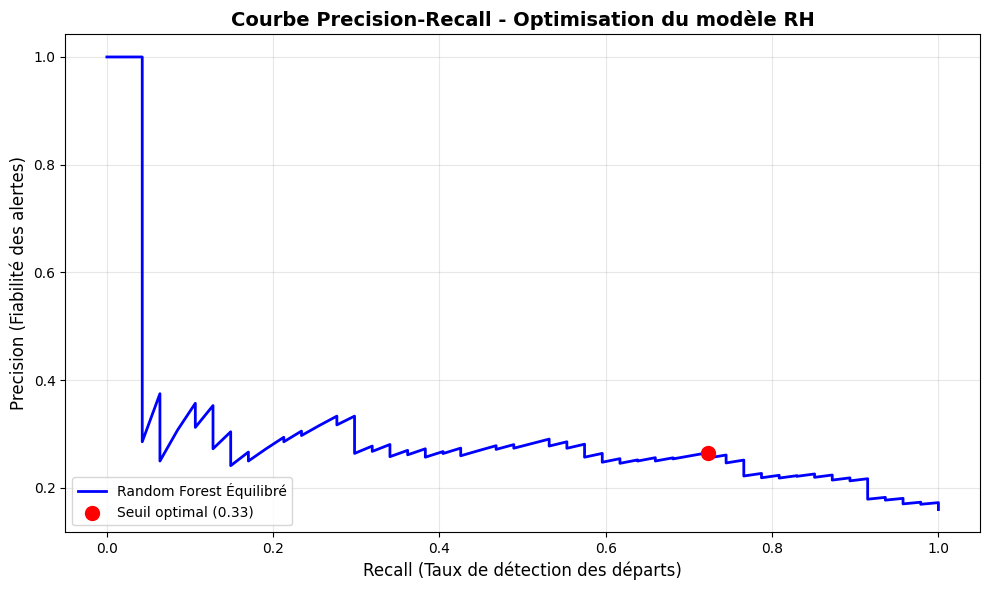

In [14]:
# 1. Calcul des probabilités de départ sur le jeu de test
y_probs = rf_balanced.predict_proba(X_test)[:, 1] # Probabilité de la classe 1 (Départ)

# 2. Calcul des points de la courbe Precision-Recall
precisions, recalls, seuils = precision_recall_curve(y_test, y_probs)

# 3. Recherche du seuil qui maximise le F1-Score
# Attention : la liste 'seuils' a un élément de moins que precisions/recalls
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
meilleur_index = np.argmax(f1_scores)
meilleur_seuil = seuils[meilleur_index]

print(f"🎯 Le seuil de probabilité optimal (pour maximiser le F1) est : {meilleur_seuil:.3f}")

# 4. Tracé du graphique
plt.figure(figsize=(10, 6))
plt.plot(recalls, precisions, label='Random Forest Équilibré', color='b', linewidth=2)
plt.scatter(recalls[meilleur_index], precisions[meilleur_index], color='red', s=100, zorder=5, 
            label=f'Seuil optimal ({meilleur_seuil:.2f})')

plt.title('Courbe Precision-Recall - Optimisation du modèle RH', fontsize=14, fontweight='bold')
plt.xlabel('Recall (Taux de détection des départs)', fontsize=12)
plt.ylabel('Precision (Fiabilité des alertes)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Application du nouveau seuil personnalisé sur le jeu de test
# Si proba > meilleur_seuil, alors 1 (Départ), sinon 0 (Reste)
y_pred_optimal = (y_probs >= meilleur_seuil).astype(int)

print("📊 Rapport de Classification Final (Avec Seuil Optimal) :")
print(classification_report(y_test, y_pred_optimal, target_names=["Reste (0)", "Part (1)"]))

📊 Rapport de Classification Final (Avec Seuil Optimal) :
              precision    recall  f1-score   support

   Reste (0)       0.92      0.62      0.74       247
    Part (1)       0.27      0.72      0.39        47

    accuracy                           0.64       294
   macro avg       0.59      0.67      0.56       294
weighted avg       0.82      0.64      0.68       294

